In [18]:
!pip -q install seaborn scikit-learn

import os
import shutil
import zipfile
import urllib.request
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, classification_report

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cpu
Device: cpu


In [19]:
REPO_URL = "https://github.com/justnahid01/CNN-Final.git"
REPO_NAME = "CNN-Final"

if os.path.exists(REPO_NAME):
    shutil.rmtree(REPO_NAME)

!git clone $REPO_URL

REPO_PATH = Path(REPO_NAME)
CUSTOM_PATH = REPO_PATH / "dataset"
MODEL_PATH = REPO_PATH / "model"

MODEL_PATH.mkdir(exist_ok=True)

print("Custom images:")

custom_images = sorted([
    f for f in CUSTOM_PATH.iterdir()
    if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
])

for image in custom_images:
    print(image.name)

print("\nTotal custom images:", len(custom_images))

Cloning into 'CNN-Final'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 16 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), 707.52 KiB | 2.34 MiB/s, done.
Custom images:
paper1.jpg
paper2.jpg
paper3.jpg
rock1.jpg
rock2.jpg
rock3.jpg
rock4.jpg
scissors1.jpg
scissors2.jpg
scissors3.jpg

Total custom images: 10


In [20]:
DATA_DIR = Path("RPS_DATA")

if DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)

DATA_DIR.mkdir()

TRAIN_URL = "https://storage.googleapis.com/download.tensorflow.org/data/rps.zip"
TEST_URL = "https://storage.googleapis.com/download.tensorflow.org/data/rps-test-set.zip"

train_zip = DATA_DIR / "rps.zip"
test_zip = DATA_DIR / "rps-test.zip"

print("Downloading training dataset...")
urllib.request.urlretrieve(TRAIN_URL, train_zip)

print("Downloading test dataset...")
urllib.request.urlretrieve(TEST_URL, test_zip)

print("Extracting...")

with zipfile.ZipFile(train_zip, "r") as z:
    z.extractall(DATA_DIR)

with zipfile.ZipFile(test_zip, "r") as z:
    z.extractall(DATA_DIR)

print("Dataset ready.")

Extracting...
Dataset ready.


In [21]:
IMAGE_SIZE = 128
BATCH_SIZE = 64

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

train_path = DATA_DIR / "rps"
test_path = DATA_DIR / "rps-test-set"

# Full datasets
full_train_aug = datasets.ImageFolder(
    train_path,
    transform=train_transform
)

full_train_eval = datasets.ImageFolder(
    train_path,
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    test_path,
    transform=eval_transform
)

class_names = full_train_eval.classes

print("Classes:", class_names)
print("Training images:", len(full_train_aug))
print("Test images:", len(test_dataset))

# 80/20 split
indices = list(range(len(full_train_aug)))
random.Random(SEED).shuffle(indices)

split = int(0.8 * len(indices))

train_indices = indices[:split]
val_indices = indices[split:]

train_dataset = Subset(full_train_aug, train_indices)
val_dataset = Subset(full_train_eval, val_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Classes: ['paper', 'rock', 'scissors']
Training images: 2520
Test images: 372
Training samples: 2016
Validation samples: 504
Test samples: 372


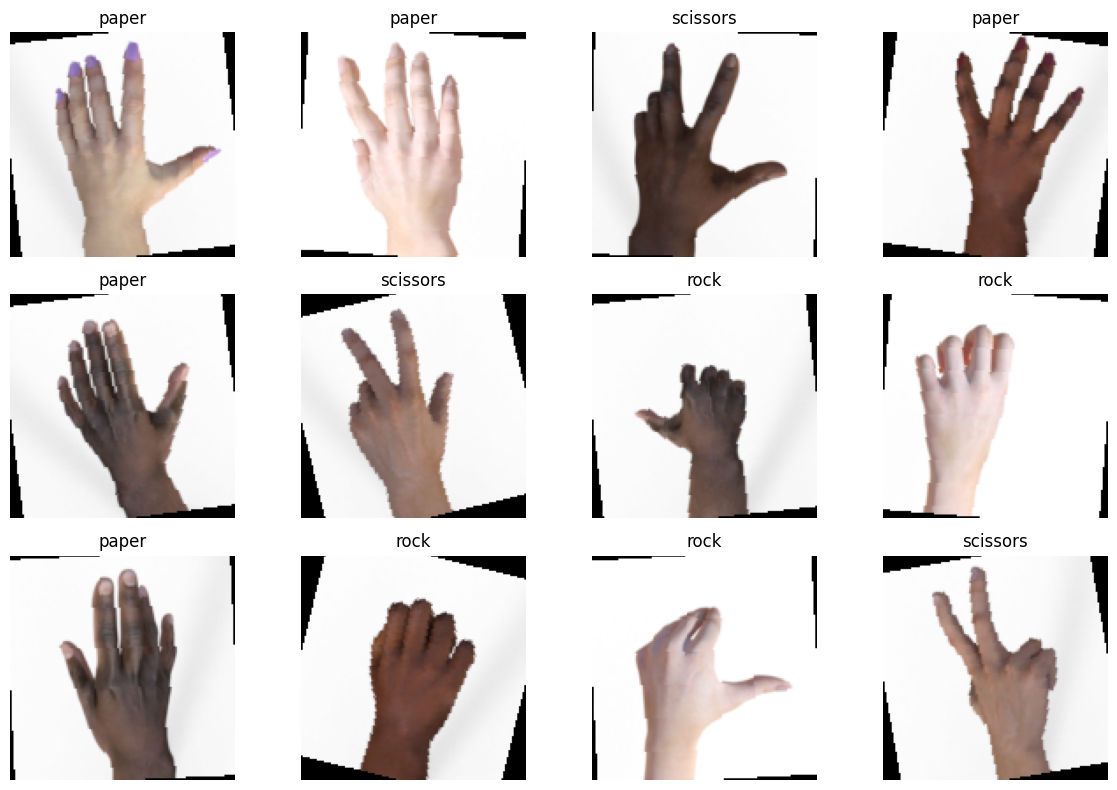

In [22]:
images, labels = next(iter(train_loader))

mean = torch.tensor(MEAN).view(3, 1, 1)
std = torch.tensor(STD).view(3, 1, 1)

plt.figure(figsize=(12, 8))

for i in range(12):
    img = images[i] * std + mean
    img = torch.clamp(img, 0, 1)

    plt.subplot(3, 4, i + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(class_names[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [23]:
class CNN(nn.Module):

    def __init__(self, num_classes=3):
        super(CNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CNN(num_classes=3).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=3, bias=True)
  )
)


In [24]:
EPOCHS = 15

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_acc = 0

print("Training started...\n")

for epoch in range(EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(1)

        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = 100 * train_correct / train_total

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(1)

            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = 100 * val_correct / val_total

    # Save history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # Save best model
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_model.pth"
        )

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

print("\nTraining completed.")
print(f"Best validation accuracy: {best_val_acc:.2f}%")

Training started...

Epoch [1/15] Train Loss: 0.9222 | Train Acc: 54.32% | Val Loss: 0.3952 | Val Acc: 88.10%
Epoch [2/15] Train Loss: 0.2129 | Train Acc: 93.11% | Val Loss: 0.0523 | Val Acc: 99.21%
Epoch [3/15] Train Loss: 0.0665 | Train Acc: 98.21% | Val Loss: 0.0449 | Val Acc: 98.81%
Epoch [4/15] Train Loss: 0.0494 | Train Acc: 98.51% | Val Loss: 0.0097 | Val Acc: 99.80%
Epoch [5/15] Train Loss: 0.0327 | Train Acc: 99.01% | Val Loss: 0.0068 | Val Acc: 99.80%
Epoch [6/15] Train Loss: 0.0177 | Train Acc: 99.55% | Val Loss: 0.0043 | Val Acc: 100.00%
Epoch [7/15] Train Loss: 0.0190 | Train Acc: 99.65% | Val Loss: 0.0024 | Val Acc: 100.00%
Epoch [8/15] Train Loss: 0.0135 | Train Acc: 99.75% | Val Loss: 0.0014 | Val Acc: 100.00%
Epoch [9/15] Train Loss: 0.0090 | Train Acc: 99.80% | Val Loss: 0.0016 | Val Acc: 100.00%
Epoch [10/15] Train Loss: 0.0103 | Train Acc: 99.60% | Val Loss: 0.0015 | Val Acc: 100.00%
Epoch [11/15] Train Loss: 0.0082 | Train Acc: 99.75% | Val Loss: 0.0010 | Val Acc: 

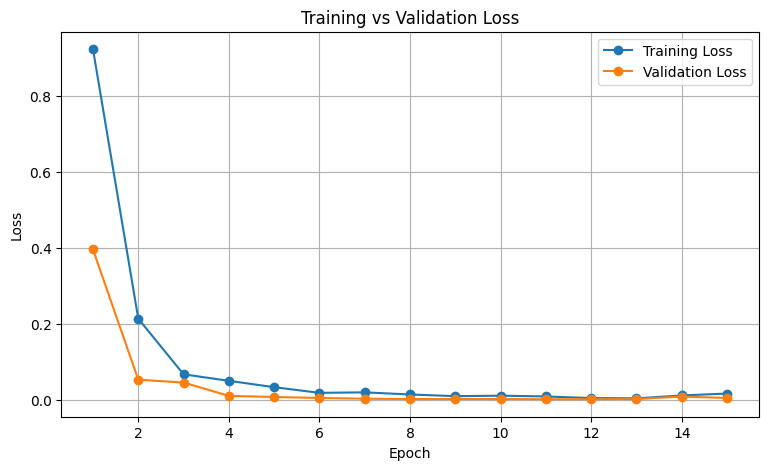

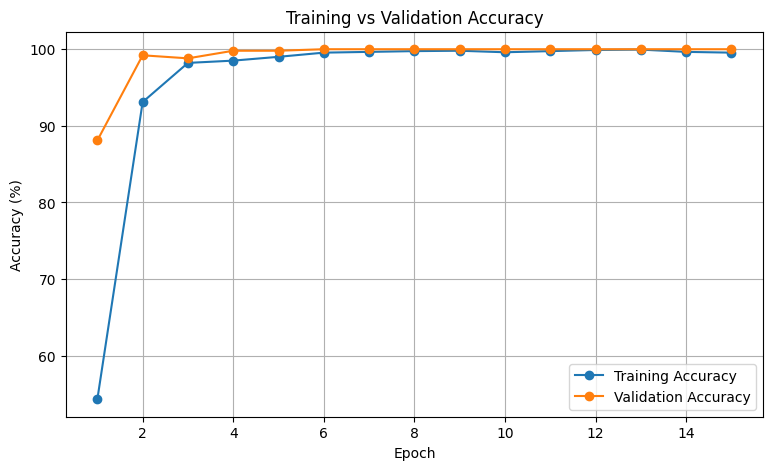

In [25]:
epochs = range(1, EPOCHS + 1)

# Loss
plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()


# Accuracy
plt.figure(figsize=(9, 5))

plt.plot(
    epochs,
    history["train_acc"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history["val_acc"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

Test Accuracy: 89.52%

Classification Report:

              precision    recall  f1-score   support

       paper       0.81      1.00      0.89       124
        rock       1.00      0.78      0.88       124
    scissors       0.93      0.90      0.91       124

    accuracy                           0.90       372
   macro avg       0.91      0.90      0.89       372
weighted avg       0.91      0.90      0.89       372



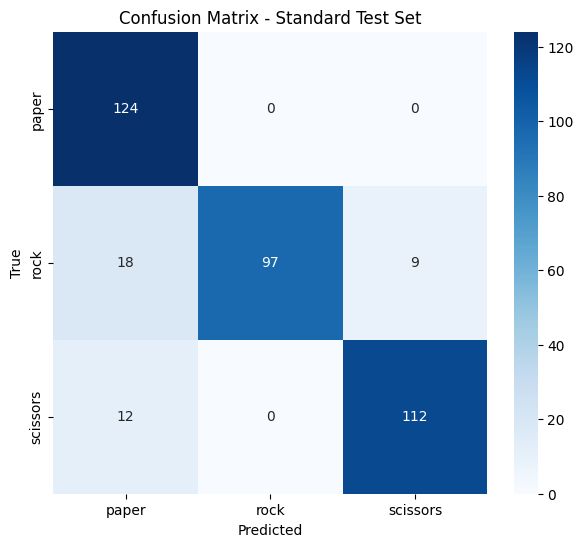

In [26]:
# Load best model
model.load_state_dict(
    torch.load(
        "best_model.pth",
        map_location=device
    )
)

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = outputs.argmax(1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(
            predictions.cpu().numpy()
        )

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)

test_accuracy = (
    all_labels == all_predictions
).mean() * 100

print(f"Test Accuracy: {test_accuracy:.2f}%")

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names
    )
)

# Confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Standard Test Set")
plt.show()

In [27]:
YOUR_ID = "220112"

FINAL_MODEL = MODEL_PATH / f"{YOUR_ID}.pth"

torch.save(
    model.state_dict(),
    FINAL_MODEL
)

print("Model saved:")
print(FINAL_MODEL)

print(
    f"Model size: "
    f"{FINAL_MODEL.stat().st_size / (1024*1024):.2f} MB"
)

Model saved:
CNN-Final/model/220112.pth
Model size: 32.36 MB


In [28]:
def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")

    tensor = eval_transform(image)

    tensor = tensor.unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        output = model(tensor)

        probabilities = torch.softmax(
            output,
            dim=1
        )[0]

        confidence, prediction = probabilities.max(0)

    return (
        class_names[prediction.item()],
        confidence.item() * 100,
        probabilities.cpu().numpy()
    )


results = []

for image_path in custom_images:

    predicted, confidence, probabilities = predict_image(
        image_path
    )

    filename = image_path.stem.lower()

    if filename.startswith("rock"):
        true_class = "rock"

    elif filename.startswith("paper"):
        true_class = "paper"

    elif filename.startswith("scissors"):
        true_class = "scissors"

    results.append({
        "filename": image_path.name,
        "true": true_class,
        "predicted": predicted,
        "confidence": confidence
    })


results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))

     filename     true predicted  confidence
   paper1.jpg    paper      rock   83.701676
   paper2.jpg    paper      rock   77.195150
   paper3.jpg    paper      rock   97.211671
    rock1.jpg     rock      rock   89.101416
    rock2.jpg     rock      rock   99.694878
    rock3.jpg     rock      rock   99.987388
    rock4.jpg     rock      rock   97.928774
scissors1.jpg scissors      rock   97.656655
scissors2.jpg scissors     paper   87.485898
scissors3.jpg scissors      rock   97.952694


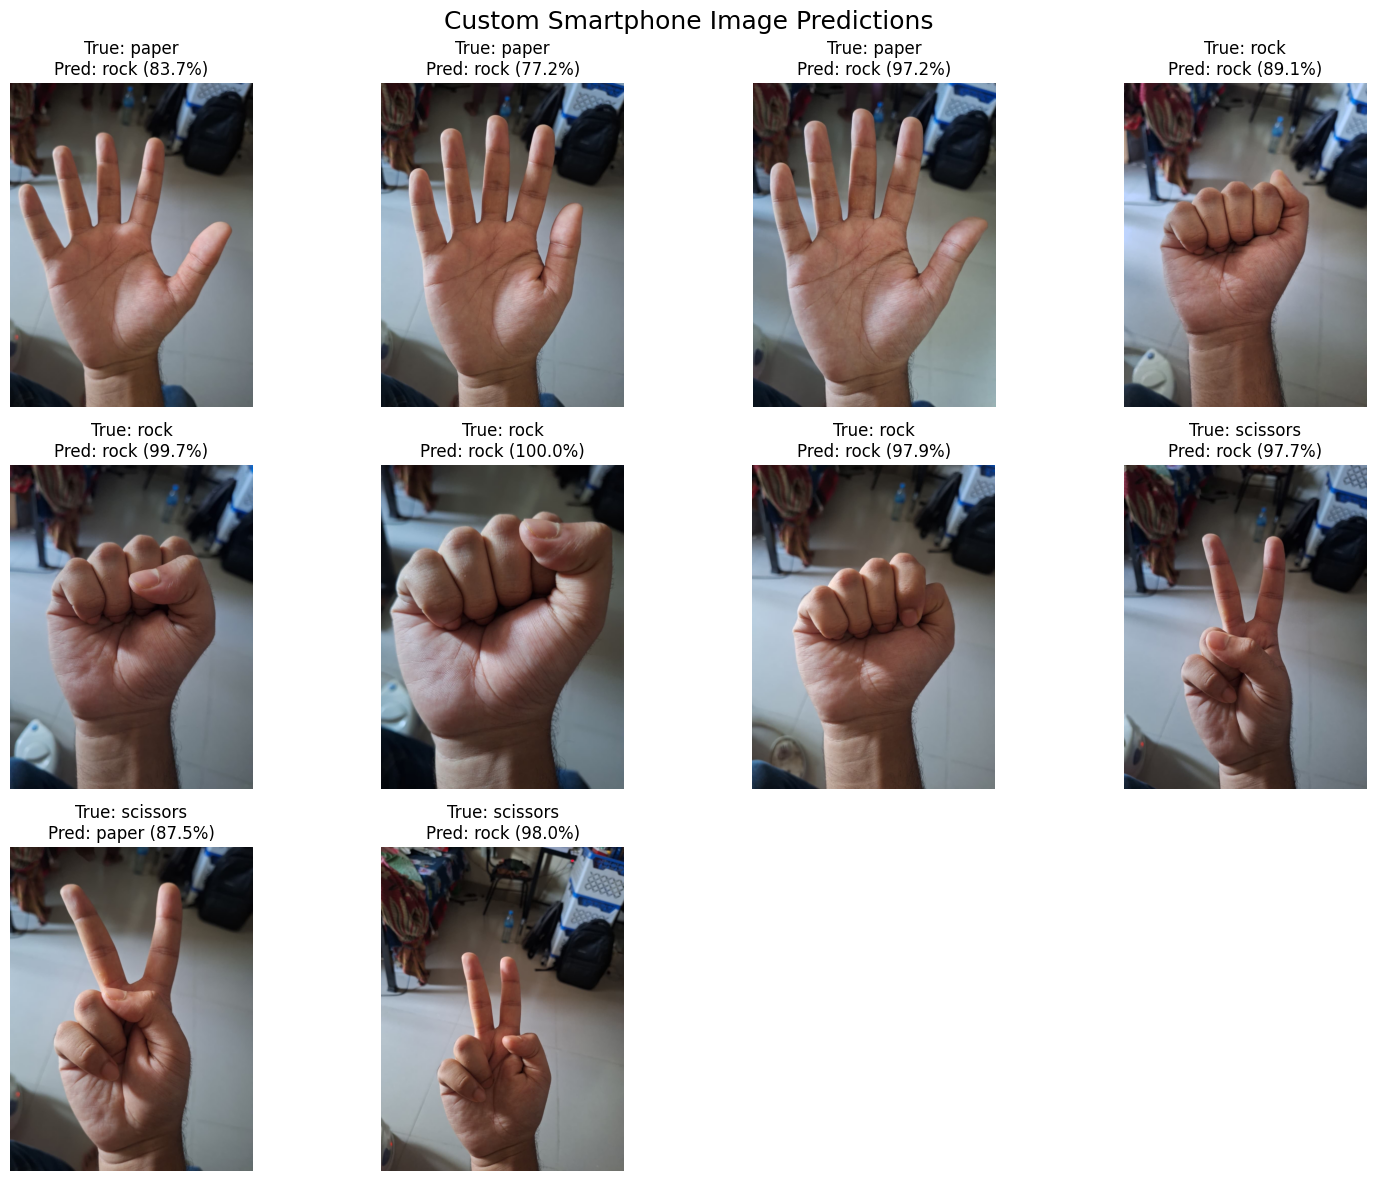

In [29]:
plt.figure(figsize=(15, 12))

for i, result in enumerate(results):

    image_path = CUSTOM_PATH / result["filename"]

    image = Image.open(image_path).convert("RGB")

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.title(
        f"True: {result['true']}\n"
        f"Pred: {result['predicted']} "
        f"({result['confidence']:.1f}%)"
    )

    plt.axis("off")

plt.suptitle(
    "Custom Smartphone Image Predictions",
    fontsize=18
)

plt.tight_layout()
plt.show()

In [30]:
custom_correct = sum(
    r["true"] == r["predicted"]
    for r in results
)

custom_total = len(results)

custom_accuracy = (
    custom_correct / custom_total
) * 100

print(
    f"Custom Image Accuracy: "
    f"{custom_accuracy:.2f}%"
)

print(
    f"Correct predictions: "
    f"{custom_correct}/{custom_total}"
)

Custom Image Accuracy: 40.00%
Correct predictions: 4/10


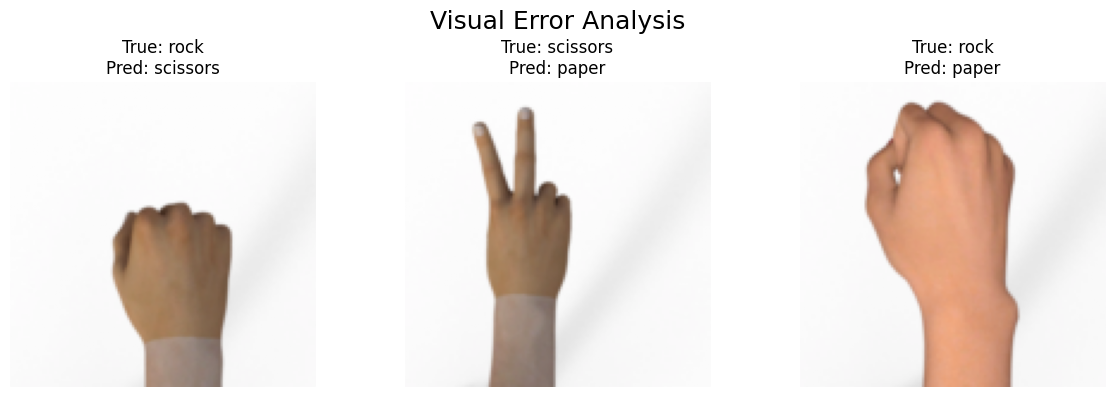

In [31]:
# Find incorrect predictions
incorrect = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(
            images.to(device)
        )

        predictions = outputs.argmax(1)

        for i in range(len(labels)):

            if predictions[i].item() != labels[i].item():

                incorrect.append({
                    "image": images[i],
                    "true": labels[i].item(),
                    "pred": predictions[i].item()
                })

# Randomly select 3
random.shuffle(incorrect)

num_errors = min(3, len(incorrect))

plt.figure(figsize=(12, 4))

for i in range(num_errors):

    sample = incorrect[i]

    image = sample["image"]

    # Undo normalization
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)

    image = image * std + mean
    image = torch.clamp(image, 0, 1)

    plt.subplot(1, 3, i + 1)

    plt.imshow(
        image.permute(1, 2, 0)
    )

    plt.title(
        f"True: {class_names[sample['true']]}\n"
        f"Pred: {class_names[sample['pred']]}"
    )

    plt.axis("off")

plt.suptitle(
    "Visual Error Analysis",
    fontsize=18
)

plt.tight_layout()
plt.show()

In [32]:
print("=" * 55)
print("ROCK-PAPER-SCISSORS CNN PROJECT")
print("=" * 55)

print(f"Training samples       : {len(train_dataset)}")
print(f"Validation samples     : {len(val_dataset)}")
print(f"Standard test samples : {len(test_dataset)}")
print(f"Custom images          : {len(custom_images)}")

print()

print(f"Best Validation Accuracy : {best_val_acc:.2f}%")
print(f"Standard Test Accuracy   : {test_accuracy:.2f}%")
print(f"Custom Image Accuracy    : {custom_accuracy:.2f}%")

print()

print("Classes:", class_names)

print()

print("Custom Predictions:")
print(results_df.to_string(index=False))

print("=" * 55)

ROCK-PAPER-SCISSORS CNN PROJECT
Training samples       : 2016
Validation samples     : 504
Standard test samples : 372
Custom images          : 10

Best Validation Accuracy : 100.00%
Standard Test Accuracy   : 89.52%
Custom Image Accuracy    : 40.00%

Classes: ['paper', 'rock', 'scissors']

Custom Predictions:
     filename     true predicted  confidence
   paper1.jpg    paper      rock   83.701676
   paper2.jpg    paper      rock   77.195150
   paper3.jpg    paper      rock   97.211671
    rock1.jpg     rock      rock   89.101416
    rock2.jpg     rock      rock   99.694878
    rock3.jpg     rock      rock   99.987388
    rock4.jpg     rock      rock   97.928774
scissors1.jpg scissors      rock   97.656655
scissors2.jpg scissors     paper   87.485898
scissors3.jpg scissors      rock   97.952694
